In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [35]:
# load dataset
data_train = pd.read_csv('dataset/train.csv')
data_test = pd.read_csv('dataset/test.csv')
data_train.drop(columns=["id", "order_id", "customer_unique_id",   "product_photos_qty", "product_name_length", "product_description_length", "product_id", "seller_id"] ,inplace=True)


In [36]:
data_train.head().T

,0,1,2,3,4
customer_city,sao joaquim da barra,sao paulo,ipatinga,hortolandia,taubate
customer_lat,-20.585751,-23.719311,-19.468787,-22.892792,-23.032142
customer_lng,-47.863693,-46.660397,-42.563895,-47.173849,-45.570461
seller_city,curitiba,ribeirao preto,ibitinga,ibitinga,limeira
seller_lat,-25.507014,-21.17771,-21.757321,-21.757321,-22.600004
seller_lng,-49.275963,-47.76782,-48.829744,-48.829744,-47.407129
quantity,3,1,1,1,1
price,44.99,32.49,74.9,119.9,29.99
freight_value,2.83,11.74,17.37,13.56,10.96
product_weight_g,1000.0,200.0,1800.0,2050.0,9000.0


In [37]:
data_train.dtypes
data_train.info()
data_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85159 entries, 0 to 85158
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_city                  85159 non-null  object 
 1   customer_lat                   84930 non-null  float64
 2   customer_lng                   84930 non-null  float64
 3   seller_city                    85159 non-null  object 
 4   seller_lat                     84954 non-null  float64
 5   seller_lng                     84954 non-null  float64
 6   quantity                       85159 non-null  int64  
 7   price                          85159 non-null  float64
 8   freight_value                  85159 non-null  float64
 9   product_weight_g               85143 non-null  float64
 10  product_length_cm              85143 non-null  float64
 11  product_height_cm              85143 non-null  float64
 12  product_width_cm               85143 non-null 

,customer_lat,customer_lng,seller_lat,seller_lng,quantity,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3,delivery_time_days
count,84930.000000,84930.000000,84954.000000,84954.000000,85159.000000,85159.000000,85159.000000,85143.000000,85143.000000,85143.00000,85143.000000,85143.000000,85159.000000
mean,-21.179249,-46.181791,-22.803836,-47.252627,1.102009,123.859738,19.727369,2138.414432,30.378763,16.51895,23.206241,15479.318147,13.230167
std,5.627527,4.073638,2.621102,2.330799,0.463198,186.098381,15.120614,3808.452404,16.269785,13.47665,11.870389,23666.565826,9.899207
min,-33.689948,-72.668881,-32.079231,-63.893565,1.000000,0.850000,0.000000,2.000000,7.000000,2.00000,6.000000,288.000000,0.530000
25%,-23.589138,-48.180222,-23.609500,-48.829744,1.000000,40.000000,13.140000,300.000000,18.000000,8.00000,15.000000,2850.000000,7.110000
50%,-22.919618,-46.628988,-23.413770,-46.755753,1.000000,78.990000,16.150000,700.000000,25.000000,13.00000,20.000000,6600.000000,11.000000
75%,-20.077863,-43.573620,-21.757321,-46.522287,1.000000,139.000000,20.850000,1825.000000,38.000000,20.00000,30.000000,18954.000000,16.520000
max,22.567952,-23.583939,-2.501242,-34.855616,20.000000,6735.000000,409.680000,40425.000000,105.000000,105.00000,118.000000,294000.000000,209.630000


In [38]:
data_train.isnull().sum()

customer_city                       0
customer_lat                      229
customer_lng                      229
seller_city                         0
seller_lat                        205
seller_lng                        205
quantity                            0
price                               0
freight_value                       0
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
volume_cm3                         16
product_category_name_english    1329
order_purchase_timestamp            0
order_approved_at                   0
delivery_time_days                  0
dtype: int64

In [30]:
data_train.nunique()

product_id                       27525
customer_city                     3920
customer_lat                     14222
customer_lng                     14222
seller_id                         2568
seller_city                        547
seller_lat                        1928
seller_lng                        1928
quantity                            15
price                             5164
freight_value                     6320
product_weight_g                  2020
product_length_cm                   99
product_height_cm                  102
product_width_cm                    94
volume_cm3                        4131
product_photos_qty                  19
product_name_length                 65
product_description_length        2807
product_category_name_english       71
order_purchase_timestamp         10596
order_approved_at                10330
delivery_time_days                5006
dtype: int64

In [47]:
purchase_ts = pd.to_datetime(data_train["order_purchase_timestamp"], errors="coerce")
approved_ts = pd.to_datetime(data_train["order_approved_at"], errors="coerce")

same_day_approval = purchase_ts.dt.date == approved_ts.dt.date
same_day_approval = same_day_approval.fillna(False)

print("Proportion d'ordres approuvés le même jour que l'achat :")
print(f"{same_day_approval.mean():.2%}")
print()
print("Répartition :")
print(same_day_approval.value_counts())

data_train["same_day_approval"] = same_day_approval
print()
print("Délai de livraison selon approbation le même jour :")
print(data_train.groupby("same_day_approval")["delivery_time_days"]
      .agg(n="count", mean="mean", median="median", std="std"))

Proportion d'ordres approuvés le même jour que l'achat :
69.61%

Répartition :
True     59277
False    25882
Name: count, dtype: int64

Délai de livraison selon approbation le même jour :
                       n       mean  median      std
same_day_approval                                   
False              25882  14.284918   12.15  9.90354
True               59277  12.769633   10.40  9.86208


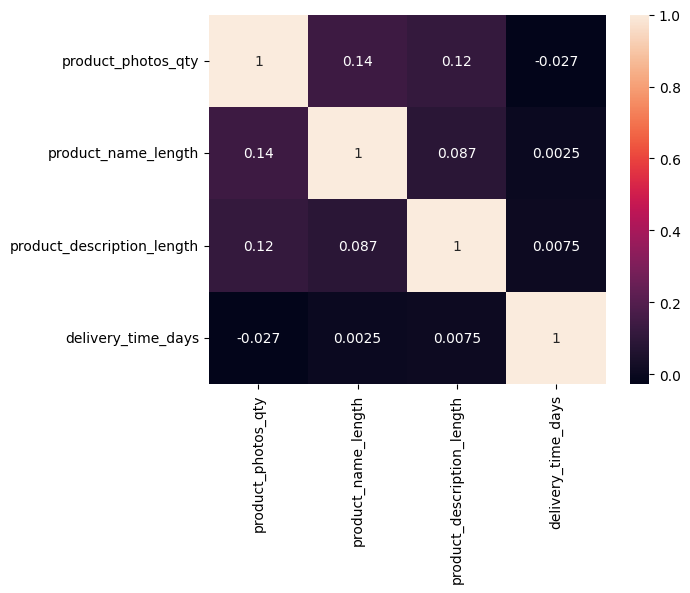

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data_train[[
    "product_photos_qty",
    "product_name_length",
    "product_description_length",
    "delivery_time_days"
]].corr(), annot=True)
plt.show()

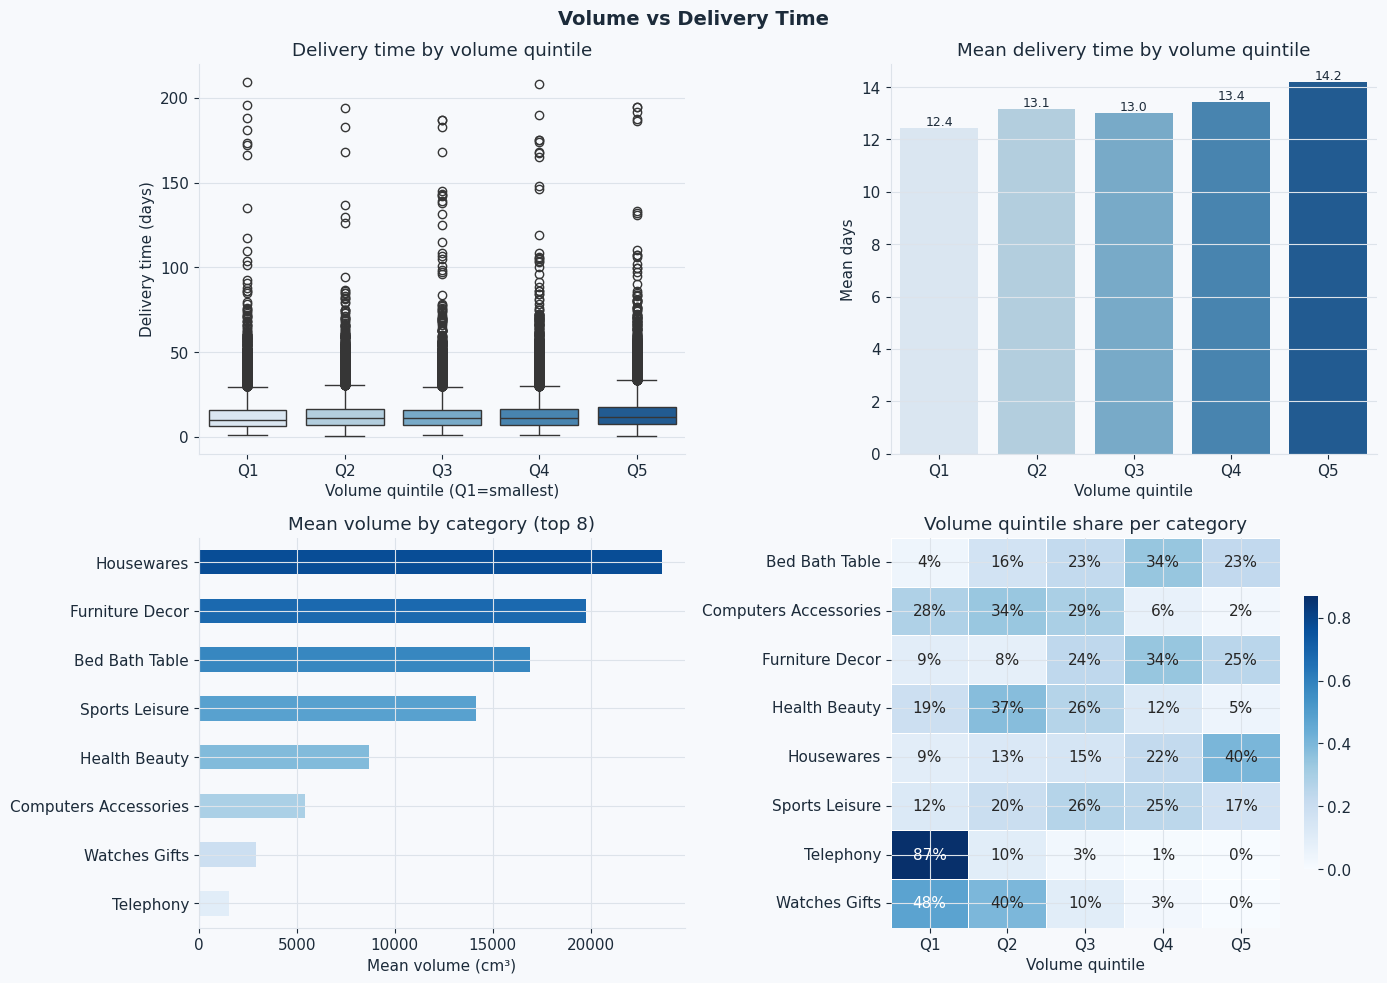

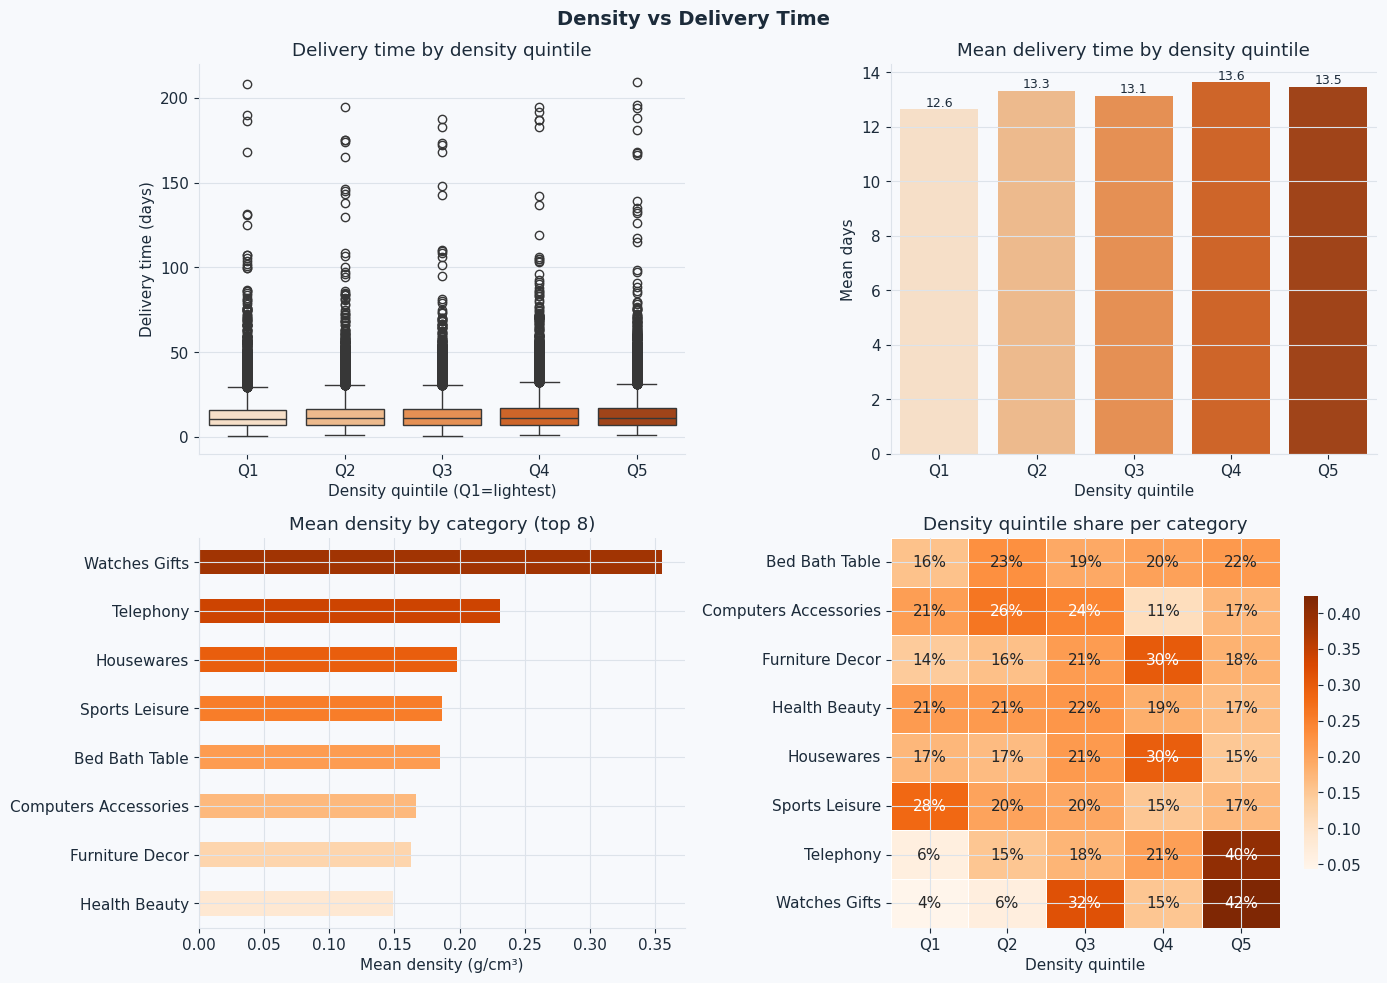

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

VOLUME_COL   = "volume_cm3"
TARGET_COL   = "delivery_time_days"
CATEGORY_COL = "product_category_name_english"
TOP_N        = 8

# --- prep ---
df = data_train[[VOLUME_COL, TARGET_COL, CATEGORY_COL]].dropna().copy()
df["volume_bin"] = pd.qcut(df[VOLUME_COL], q=5, duplicates="drop",
                            labels=["Q1","Q2","Q3","Q4","Q5"])

top_cats = df[CATEGORY_COL].value_counts().head(TOP_N).index
df_top   = df[df[CATEGORY_COL].isin(top_cats)]

# --- figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Volume vs Delivery Time", fontsize=14, fontweight="bold")

# 1. distribution du délai par quintile de volume
sns.boxplot(data=df, x="volume_bin", y=TARGET_COL, ax=axes[0,0],
            palette="Blues", hue="volume_bin", legend=False)
axes[0,0].set_title("Delivery time by volume quintile")
axes[0,0].set_xlabel("Volume quintile (Q1=smallest)")
axes[0,0].set_ylabel("Delivery time (days)")

# 2. délai moyen par quintile
stats = df.groupby("volume_bin", observed=True)[TARGET_COL].mean().reset_index()
sns.barplot(data=stats, x="volume_bin", y=TARGET_COL, ax=axes[0,1],
            palette="Blues", hue="volume_bin", legend=False)
axes[0,1].set_title("Mean delivery time by volume quintile")
axes[0,1].set_xlabel("Volume quintile")
axes[0,1].set_ylabel("Mean days")
for p in axes[0,1].patches:
    axes[0,1].annotate(f"{p.get_height():.1f}",
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha="center", va="bottom", fontsize=9)

# 3. volume moyen par catégorie
cat_vol = df_top.groupby(CATEGORY_COL)[VOLUME_COL].mean().sort_values()
cat_vol.index = cat_vol.index.str.replace("_", " ").str.title()
cat_vol.plot(kind="barh", ax=axes[1,0], color=sns.color_palette("Blues", len(cat_vol)))
axes[1,0].set_title(f"Mean volume by category (top {TOP_N})")
axes[1,0].set_xlabel("Mean volume (cm³)")
axes[1,0].set_ylabel("")

# 4. heatmap répartition quintile × catégorie
mix = pd.crosstab(df_top[CATEGORY_COL], df_top["volume_bin"], normalize="index")
mix.index = mix.index.str.replace("_", " ").str.title()
sns.heatmap(mix, annot=True, fmt=".0%", cmap="Blues", ax=axes[1,1],
            linewidths=0.4, cbar_kws={"shrink": 0.7})
axes[1,1].set_title("Volume quintile share per category")
axes[1,1].set_xlabel("Volume quintile")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.savefig("volume_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


# ── DENSITÉ ─────────────────────────────────────────────────────
WEIGHT_COL = "product_weight_g"  # ← adapte si besoin

df2 = data_train[[VOLUME_COL, WEIGHT_COL, TARGET_COL, CATEGORY_COL]].dropna().copy()
df2["density"] = df2[WEIGHT_COL] / df2[VOLUME_COL]  # g/cm³

df2["density_bin"] = pd.qcut(df2["density"], q=5, duplicates="drop",
                              labels=["Q1","Q2","Q3","Q4","Q5"])

top_cats2 = df2[CATEGORY_COL].value_counts().head(TOP_N).index
df2_top   = df2[df2[CATEGORY_COL].isin(top_cats2)]

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("Density vs Delivery Time", fontsize=14, fontweight="bold")

# 1. distribution du délai par quintile de densité
sns.boxplot(data=df2, x="density_bin", y=TARGET_COL, ax=axes2[0,0],
            palette="Oranges", hue="density_bin", legend=False)
axes2[0,0].set_title("Delivery time by density quintile")
axes2[0,0].set_xlabel("Density quintile (Q1=lightest)")
axes2[0,0].set_ylabel("Delivery time (days)")

# 2. délai moyen par quintile de densité
stats2 = df2.groupby("density_bin", observed=True)[TARGET_COL].mean().reset_index()
sns.barplot(data=stats2, x="density_bin", y=TARGET_COL, ax=axes2[0,1],
            palette="Oranges", hue="density_bin", legend=False)
axes2[0,1].set_title("Mean delivery time by density quintile")
axes2[0,1].set_xlabel("Density quintile")
axes2[0,1].set_ylabel("Mean days")
for p in axes2[0,1].patches:
    axes2[0,1].annotate(f"{p.get_height():.1f}",
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# 3. densité moyenne par catégorie
cat_dens = df2_top.groupby(CATEGORY_COL)["density"].mean().sort_values()
cat_dens.index = cat_dens.index.str.replace("_", " ").str.title()
cat_dens.plot(kind="barh", ax=axes2[1,0], color=sns.color_palette("Oranges", len(cat_dens)))
axes2[1,0].set_title(f"Mean density by category (top {TOP_N})")
axes2[1,0].set_xlabel("Mean density (g/cm³)")
axes2[1,0].set_ylabel("")

# 4. heatmap répartition quintile densité × catégorie
mix2 = pd.crosstab(df2_top[CATEGORY_COL], df2_top["density_bin"], normalize="index")
mix2.index = mix2.index.str.replace("_", " ").str.title()
sns.heatmap(mix2, annot=True, fmt=".0%", cmap="Oranges", ax=axes2[1,1],
            linewidths=0.4, cbar_kws={"shrink": 0.7})
axes2[1,1].set_title("Density quintile share per category")
axes2[1,1].set_xlabel("Density quintile")
axes2[1,1].set_ylabel("")

plt.tight_layout()
plt.savefig("density_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

count    85159.000000
mean        13.230167
std          9.899207
min          0.530000
25%          7.110000
50%         11.000000
75%         16.520000
max        209.630000
Name: delivery_time_days, dtype: float64


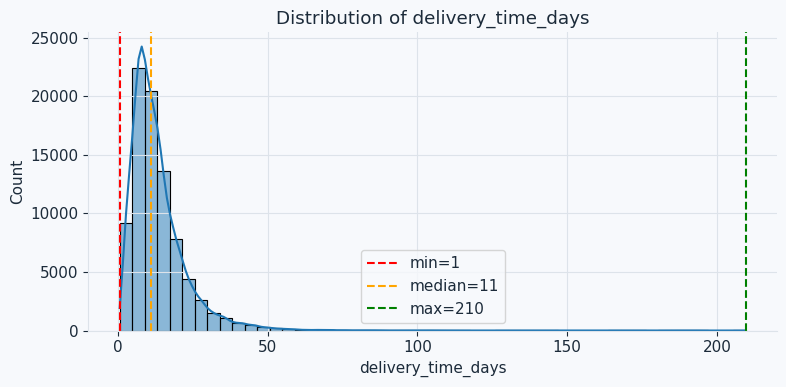

In [48]:
print(data_train["delivery_time_days"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(data_train["delivery_time_days"], bins=50, kde=True)
plt.axvline(data_train["delivery_time_days"].min(), color="red", linestyle="--", label=f'min={data_train["delivery_time_days"].min():.0f}')
plt.axvline(data_train["delivery_time_days"].median(), color="orange", linestyle="--", label=f'median={data_train["delivery_time_days"].median():.0f}')
plt.axvline(data_train["delivery_time_days"].max(), color="green", linestyle="--", label=f'max={data_train["delivery_time_days"].max():.0f}')
plt.title("Distribution of delivery_time_days")
plt.legend()
plt.tight_layout()
plt.show()

Outliers : 1597 lignes (1.88%)
Borne basse : -19.6  |  Borne haute : 41.0


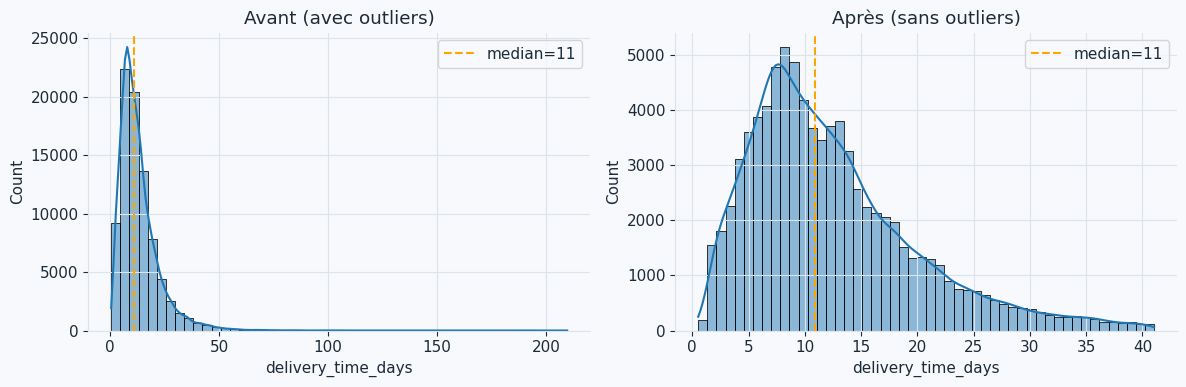

Min : 0.53
Max : 209.63
Bornes IQR : [-19.6, 41.0]
Valeurs supprimées : 1597 (1.88%)
60808     41.06
49461     41.06
61446     41.07
29254     41.07
14798     41.08
59883     41.08
45090     41.09
61451     41.09
47486     41.09
38392     41.09
62669     41.10
53194     41.11
49747     41.12
63316     41.12
9782      41.12
38157     41.13
42241     41.13
60816     41.14
21567     41.14
43217     41.14
39076     41.14
52336     41.14
59699     41.15
58014     41.16
57281     41.18
47975     41.18
39435     41.18
61581     41.18
51059     41.19
44455     41.19
58981     41.21
58756     41.23
30978     41.23
59704     41.23
185       41.23
37494     41.23
62362     41.23
59245     41.24
36408     41.24
60784     41.24
39687     41.24
53559     41.25
4021      41.25
35877     41.25
62860     41.26
49209     41.27
36575     41.27
50008     41.27
61077     41.28
9885      41.29
76118     41.30
61476     41.30
60842     41.31
83161     41.32
34713     41.32
57680     41.32
36259     41.33
506

In [53]:
Q1 = data_train["delivery_time_days"].quantile(0.05)
Q3 = data_train["delivery_time_days"].quantile(0.8)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data_train[(data_train["delivery_time_days"] < lower) | (data_train["delivery_time_days"] > upper)]
print(f"Outliers : {len(outliers)} lignes ({len(outliers)/len(data_train):.2%})")
print(f"Borne basse : {lower:.1f}  |  Borne haute : {upper:.1f}")

data_train_clean = data_train[
    (data_train["delivery_time_days"] >= lower) &
    (data_train["delivery_time_days"] <= upper)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes,
                          [data_train, data_train_clean],
                          ["Avant (avec outliers)", "Après (sans outliers)"]):
    sns.histplot(df["delivery_time_days"], bins=50, kde=True, ax=ax)
    ax.axvline(df["delivery_time_days"].median(), color="orange", linestyle="--",
               label=f'median={df["delivery_time_days"].median():.0f}')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()
print(f"Min : {data_train['delivery_time_days'].min()}")
print(f"Max : {data_train['delivery_time_days'].max()}")
print(f"Bornes IQR : [{lower:.1f}, {upper:.1f}]")
print(f"Valeurs supprimées : {len(outliers)} ({len(outliers)/len(data_train):.2%})")
print(outliers["delivery_time_days"].sort_values().to_string())